# How do socio-economic and housing characteristics influence the spatial distribution of domestic (rooftop) solar PV adoption across the UK?

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

### Import Files

In [2]:
# FiT installation data
file_path1 = os.path.join("..", "data", "FIT data", "Feed-in Tariff installation report part 1_0.xlsx")
file_path2 = os.path.join("..", "data", "FIT data", "Feed-in Tariff installation report part 2_0.xlsx")
file_path3 = os.path.join("..", "data", "FIT data", "Feed-in Tariff installation report part 3_0.xlsx")

df1 = pd.read_excel(file_path1,header=4)
df2 = pd.read_excel(file_path2,header=4)
df3 = pd.read_excel(file_path3,header=4)

print("Loaded FiT parts:", df1.shape, df2.shape, df3.shape)

Loaded FiT parts: (289934, 21) (289934, 21) (869803, 22)


## Part 1 - Combine & Inspect FiT Dataset

In [3]:
df = pd.concat([df1, df2, df3], ignore_index = True)

In [4]:
# Clean LLSOA Codes in every dataset: 

df['LLSOA Code'] = df['LLSOA Code'].str.strip().str.upper()

In [5]:
# To define the main column name used across all datasets: 

LSOA = 'LLSOA Code'

In [6]:
df[LSOA].nunique() == len(df)

False

In [7]:
# Clean LSOA Codes for each dataset: 

def clean_lsoa(df):
    df[LSOA] = (
        df[LSOA]
        .astype(str)
        .str.strip()
        .str.upper()
    )
    return df

In [8]:
# Cleaned datasets: 

df1 = clean_lsoa(df1)
df2 = clean_lsoa(df2)
df3 = clean_lsoa(df3)

In [9]:
# Filter to England and Wales: 

df = df[df[LSOA].str.startswith(("E", "W"), na=False)]

In [10]:
# The result is not equal, hence we aggregate: 

print(df1[LSOA].nunique(), len(df1))

34708 289934


In [11]:
# Clean LSOA column: 

df[LSOA] = df[LSOA].astype(str).str.strip().str.upper()

In [12]:
# Remove invalid rows i.e. Scotland, only keep England and Wales: 

df = df[df[LSOA].notna()]
df = df[df[LSOA].str.startswith(('E','W'))]

In [13]:
# Check: 

print('Rows:', len(df))
print('Unique LSOA:', df[LSOA].nunique())

# The result/output shows: 
# 1.33 million rows are individual PV installations (raw FIT data)
# 34,017 LSOAs are geographic areas in England & Wales

Rows: 1333712
Unique LSOA: 34017


In [14]:
df.columns

Index(['Extension (Y/N)', 'PostCode ', 'Technology', 'Installed capacity',
       'Declared net capacity', 'Application date ', 'Commissioning date',
       'MCS issue date', 'Export status', 'TariffCode', 'Tariff Description',
       'Installation Type', 'Installation Country', 'Government Office Region',
       'Local Authority', 'Constituency', 'Accreditation Route', 'MPAN Prefix',
       'Community school category', 'LLSOA Code', 'MLSOA Code', 'crime'],
      dtype='object')

## Step 2: Construct the Dependent Variable (Domestic PV Adoption)

###### Step 2.1 - Extract PV installations only

In [15]:
# Filtering for Photovoltaic technology AND Domestic installations
df = df[(df['Technology'] == 'Photovoltaic') & (df['Installation Type'] == 'Domestic')].copy()

###### Step 2.2 - Aggregate installations by postcode

In [16]:
# It has been aggregated by LSOA instead. Is Postcode a must, instead of aggregating by LSOA? 

###### Step 2.3 - Aggregate to LSOA: 

In [17]:
# Installed Capacity is the column used to aggregrate: 

lsoa_pv = df.groupby('LLSOA Code').agg(total_installations=('LLSOA Code', 'count'), total_capacity_kw=('Installed capacity', 'sum')).reset_index()

# total_installations: counts how many PV installations per LSOA
# total_capacity_kw: sums the installed capacity (kW) per LSOA

In [18]:
lsoa_pv.columns

Index(['LLSOA Code', 'total_installations', 'total_capacity_kw'], dtype='object')

In [19]:
# Check: 

print(len(lsoa_pv)) 
print(lsoa_pv["LLSOA Code"].nunique()) 
lsoa_pv.describe()

# The result is 34016 LSOAs with PV installations, and the total number of rows is also 34016, which means each row corresponds to a unique LSOA.

33814
33814


,total_installations,total_capacity_kw
count,33814.000000,33814.000000
mean,22.641657,79.574194
std,22.672674,87.949892
min,1.000000,0.740000
25%,7.000000,24.452500
50%,16.000000,54.350000
75%,30.000000,104.727500
max,346.000000,5475.450000


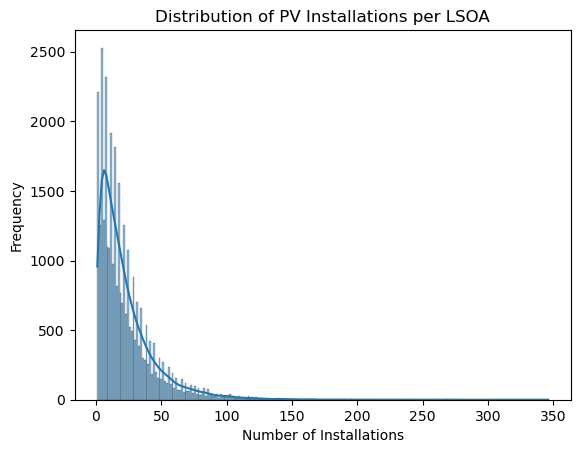

In [20]:
# Check the distribution as a Visual: 

sns.histplot(lsoa_pv["total_installations"], kde=True)
plt.title("Distribution of PV Installations per LSOA")
plt.xlabel("Number of Installations")
plt.ylabel("Frequency")
plt.show()

In [21]:
file_path4 = os.path.join("..", "data", "Census data", "TS041-2021-3-filtered-2026-03-31T12_29_48Z.csv")

households_total = pd.read_csv(file_path4)

In [22]:
households_total = households_total.rename(columns={'Lower layer Super Output Areas Code': 'LLSOA Code'})
households_total.head()

,LLSOA Code,Lower layer Super Output Areas,Observation
0,E01000001,City of London 001A,838
1,E01000002,City of London 001B,824
2,E01000003,City of London 001C,1017
3,E01000005,City of London 001E,480
4,E01000006,Barking and Dagenham 016A,554


In [23]:
# Aggregate to get one row per LLSOA by summing the 'Observation' column to get the total number of households
households_summed = households_total.groupby('LLSOA Code')['Observation'].sum().reset_index()

# Rename 'Observation' to 'Total Households'
households_summed = households_summed.rename(columns={'Observation': 'Total Households'})

In [24]:
households_summed.head()

,LLSOA Code,Total Households
0,E01000001,838
1,E01000002,824
2,E01000003,1017
3,E01000005,480
4,E01000006,554


###### Step 2.4 - Merge with PV Dataset: 

In [25]:
len(households_summed)

35672

In [26]:
# Merge: 

lsoa_pv = lsoa_pv.merge(households_summed, on='LLSOA Code', how='left')
len(lsoa_pv)

33814

In [27]:
lsoa_pv.head()


,LLSOA Code,total_installations,total_capacity_kw,Total Households
0,E01000003,1,21.00,1017.0
1,E01000006,5,11.63,554.0
2,E01000008,1,2.50,548.0
3,E01000011,1,2.80,473.0
4,E01000012,2,30.75,783.0


In [28]:
# Normalise PV adoption: 

lsoa_pv['capacity_per_1000_households'] = (lsoa_pv['total_capacity_kw'] / lsoa_pv['Total Households']) * 1000
lsoa_pv['installations_per_household'] = lsoa_pv['total_installations'] / lsoa_pv['Total Households']

In [29]:
# Check: 

lsoa_pv[['total_installations', 'total_capacity_kw', 'Total Households', 
         'capacity_per_1000_households', 'installations_per_household']].describe()

,total_installations,total_capacity_kw,Total Households,capacity_per_1000_households,installations_per_household
count,33814.000000,33814.000000,32786.000000,32786.000000,32786.000000
mean,22.641657,79.574194,696.893705,113.318113,0.032326
std,22.672674,87.949892,143.119111,124.860129,0.030897
min,1.000000,0.740000,402.000000,0.760389,0.000833
25%,7.000000,24.452500,603.000000,36.217570,0.011164
50%,16.000000,54.350000,667.000000,79.805469,0.023660
75%,30.000000,104.727500,770.000000,151.381664,0.043436
max,346.000000,5475.450000,1336.000000,9883.483755,0.402695


In [30]:
df['Installation Type'].value_counts()

Installation Type
Domestic    765605
Name: count, dtype: int64

In [31]:
lsoa_pv.head()

,LLSOA Code,total_installations,total_capacity_kw,Total Households,capacity_per_1000_households,installations_per_household
0,E01000003,1,21.00,1017.0,20.648968,0.000983
1,E01000006,5,11.63,554.0,20.992780,0.009025
2,E01000008,1,2.50,548.0,4.562044,0.001825
3,E01000011,1,2.80,473.0,5.919662,0.002114
4,E01000012,2,30.75,783.0,39.272031,0.002554


###### Step 2.5 - Normalise: 

In [32]:
# lsoa_pv is the dependent variable

# Step 3: Add Socio-Economic & Housing Explanatory Variables

In [33]:
file_path4 = os.path.join("..", "data", "Census data", "TS017-2021-1-filtered-2026-03-30T15_36_20Z.csv")
file_path5 = os.path.join("..", "data", "Census data", "TS044-2021-1-filtered-2026-03-30T15_35_49Z.csv")
file_path6 = os.path.join("..", "data", "Census data", "census2021-ts007a-lsoa.csv")
file_path7 = os.path.join("..", "data", "Census data", "TS066-2021-1-filtered-2026-03-30T15_36_57Z.csv")
file_path8 = os.path.join("..", "data", "Census data", "TS054-2021-1-filtered-2026-03-30T15_35_18Z.csv")


household_size = pd.read_csv(file_path4)
housing_type = pd.read_csv(file_path5)
age = pd.read_csv(file_path6)
economic = pd.read_csv(file_path7)
ownership_status = pd.read_csv(file_path8)

###### Housing Size: 

In [34]:
household_size.head()

,Lower layer Super Output Areas Code,Lower layer Super Output Areas,Household size (9 categories) Code,Household size (9 categories),Observation
0,E01000001,City of London 001A,0,0 people in household,0
1,E01000001,City of London 001A,1,1 person in household,371
2,E01000001,City of London 001A,2,2 people in household,350
3,E01000001,City of London 001A,3,3 people in household,70
4,E01000001,City of London 001A,4,4 people in household,41


In [35]:
household_size.columns

Index(['Lower layer Super Output Areas Code', 'Lower layer Super Output Areas',
       'Household size (9 categories) Code', 'Household size (9 categories)',
       'Observation'],
      dtype='object')

In [36]:
# Renaming columns for clarity
household_size = household_size.rename(columns={
    'Lower layer Super Output Areas Code': 'LLSOA Code',
    'Household size (9 categories)': 'size_category',
    'Household size (9 categories) Code': 'size_code',
    'Observation': 'count'
})

# Strip whitespace
household_size['LLSOA Code'] = household_size['LLSOA Code'].str.strip()

# Remove vacant/non-household rows (code 0 = 0 people)
household_size = household_size[household_size['size_code'] != 0]

# Calculate weighted average household size per LSOA
# size_code represents number of people (1,2,3...8 for 8+)
household_size['weighted'] = household_size['size_code'] * household_size['count']

avg_household_size = household_size.groupby('LLSOA Code').agg(
    total_weighted = ('weighted', 'sum'),
    total_households = ('count', 'sum')
).reset_index()

avg_household_size['avg_household_size'] = (
    avg_household_size['total_weighted'] / avg_household_size['total_households']
)

household_size_clean = avg_household_size[['LLSOA Code', 'avg_household_size']].copy()

In [37]:
household_size_clean.columns

Index(['LLSOA Code', 'avg_household_size'], dtype='object')

In [38]:
household_size_clean.describe()

,avg_household_size
count,35672.000000
mean,2.382213
std,0.320131
min,1.295943
25%,2.196809
50%,2.347519
75%,2.519179
max,5.059441


In [39]:
household_size_clean.head()

,LLSOA Code,avg_household_size
0,E01000001,1.760143
1,E01000002,1.679612
2,E01000003,1.581281
3,E01000005,2.183716
4,E01000006,3.294964


###### Housing Type: 

In [40]:
housing_type.columns

Index(['Lower layer Super Output Areas Code', 'Lower layer Super Output Areas',
       'Accommodation type (8 categories) Code',
       'Accommodation type (8 categories)', 'Observation'],
      dtype='object')

In [41]:
housing_type = housing_type.rename(columns={'Lower layer Super Output Areas Code': 'LLSOA Code'})

In [42]:
housing_type.columns

Index(['LLSOA Code', 'Lower layer Super Output Areas',
       'Accommodation type (8 categories) Code',
       'Accommodation type (8 categories)', 'Observation'],
      dtype='object')

In [43]:
housing_pivot = housing_type.pivot(
    index='LLSOA Code',
    columns='Accommodation type (8 categories)',
    values='Observation'
).reset_index()

In [44]:
housing_pivot.head()

Accommodation type (8 categories),LLSOA Code,A caravan or other mobile or temporary structure,Detached,"In a commercial building, for example, in an office building, hotel or over a shop",In a purpose-built block of flats or tenement,"Part of a converted or shared house, including bedsits","Part of another converted building, for example, former school, church or warehouse",Semi-detached,Terraced
0,E01000001,0,0,7,803,0,11,3,13
1,E01000002,0,1,9,769,2,13,2,29
2,E01000003,0,1,7,994,2,13,0,0
3,E01000005,0,0,10,457,5,5,0,2
4,E01000006,1,34,0,121,24,3,88,283


In [45]:
# To create the 'Total' variable : - 

housing_columns = housing_pivot.columns.drop('LLSOA Code')
housing_pivot['total dwellings'] = housing_pivot[housing_columns].sum(axis = 1)

In [46]:
# Calculate: - 

housing_pivot['% detached semi'] = (housing_pivot['Detached'] + housing_pivot['Semi-detached']) / housing_pivot['total dwellings']

In [47]:
housing_pivot['% detached semi'].describe()

count    35672.000000
mean         0.556843
std          0.281358
min          0.000000
25%          0.322998
50%          0.603175
75%          0.802541
max          1.000000
Name: % detached semi, dtype: float64

In [48]:
# Final Dataset: - 

housing_clean = housing_pivot[['LLSOA Code', '% detached semi']].copy()

###### Age: 

In [49]:
age.columns

Index(['date', 'geography', 'geography code', 'Age: Total',
       'Age: Aged 4 years and under', 'Age: Aged 5 to 9 years',
       'Age: Aged 10 to 14 years', 'Age: Aged 15 to 19 years',
       'Age: Aged 20 to 24 years', 'Age: Aged 25 to 29 years',
       'Age: Aged 30 to 34 years', 'Age: Aged 35 to 39 years',
       'Age: Aged 40 to 44 years', 'Age: Aged 45 to 49 years',
       'Age: Aged 50 to 54 years', 'Age: Aged 55 to 59 years',
       'Age: Aged 60 to 64 years', 'Age: Aged 65 to 69 years',
       'Age: Aged 70 to 74 years', 'Age: Aged 75 to 79 years',
       'Age: Aged 80 to 84 years', 'Age: Aged 85 years and over'],
      dtype='object')

In [50]:
age = age.rename(columns={'geography code': 'LLSOA Code'})

In [51]:
# % aged 35-64 — Peak homeownership + peak earning years — most likely to have capital and a long enough horizon to recoup investment. This is the core adopter demographic in most FIT studies

age['35-64'] = (age['Age: Aged 35 to 39 years'] +
                age['Age: Aged 40 to 44 years'] +
                age['Age: Aged 45 to 49 years'] +
                age['Age: Aged 50 to 54 years'] +
                age['Age: Aged 55 to 59 years'] +
                age['Age: Aged 60 to 64 years'])

age['% aged 35-64'] = age['35-64'] / age['Age: Total']

# % aged 65+ - Mixed effect — high homeownership rates but fixed incomes and shorter payback horizons may reduce adoption

age['65+'] = (age['Age: Aged 65 to 69 years'] +
              age['Age: Aged 70 to 74 years'] +
              age['Age: Aged 75 to 79 years'] +
              age['Age: Aged 80 to 84 years'] +
              age['Age: Aged 85 years and over'])

age['% aged 65+'] = age['65+'] / age['Age: Total']

In [52]:
age_clean = age[['LLSOA Code', '% aged 35-64', '% aged 65+']].copy()
age_clean.head()

,LLSOA Code,% aged 35-64,% aged 65+
0,E01000001,0.394433,0.251188
1,E01000002,0.431358,0.200145
2,E01000003,0.466212,0.176689
3,E01000005,0.402361,0.094460
4,E01000006,0.403909,0.085776


###### Economic: 

In [53]:
economic.columns

Index(['Lower layer Super Output Areas Code', 'Lower layer Super Output Areas',
       'Economic activity status (20 categories) Code',
       'Economic activity status (20 categories)', 'Observation'],
      dtype='object')

In [54]:
economic = economic.rename(columns={'Lower layer Super Output Areas Code': 'LLSOA Code'})

In [55]:
economic.head()

,LLSOA Code,Lower layer Super Output Areas,Economic activity status (20 categories) Code,Economic activity status (20 categories),Observation
0,E01000001,City of London 001A,-8,Does not apply,125
1,E01000001,City of London 001A,1,Economically active (excluding full-time stude...,76
2,E01000001,City of London 001A,2,Economically active (excluding full-time stude...,575
3,E01000001,City of London 001A,3,Economically active (excluding full-time stude...,1
4,E01000001,City of London 001A,4,Economically active (excluding full-time stude...,41


In [56]:
economic_pivot = economic.pivot(
    index = 'LLSOA Code', 
    columns = 'Economic activity status (20 categories)', 
    values = 'Observation'
).reset_index()

In [57]:
economic_pivot.columns

Index(['LLSOA Code', 'Does not apply',
       'Economically active (excluding full-time students): In employment: Employee: Full-time',
       'Economically active (excluding full-time students): In employment: Employee: Part-time',
       'Economically active (excluding full-time students): In employment: Self-employed with employees: Full-time',
       'Economically active (excluding full-time students): In employment: Self-employed with employees: Part-time',
       'Economically active (excluding full-time students): In employment: Self-employed without employees: Full-time',
       'Economically active (excluding full-time students): In employment: Self-employed without employees: Part-time',
       'Economically active (excluding full-time students): Unemployed: Seeking work or waiting to start a job already obtained: Available to start working within 2 weeks',
       'Economically active and a full-time student: In employment: Employee: Full-time',
       'Economically active an

In [58]:
economic_pivot['employed'] = (
    economic_pivot['Economically active (excluding full-time students): In employment: Employee: Full-time'] +
    economic_pivot['Economically active (excluding full-time students): In employment: Employee: Part-time'] +
    economic_pivot['Economically active (excluding full-time students): In employment: Self-employed with employees: Full-time'] +
    economic_pivot['Economically active (excluding full-time students): In employment: Self-employed with employees: Part-time'] +
    economic_pivot['Economically active (excluding full-time students): In employment: Self-employed without employees: Full-time'] +
    economic_pivot['Economically active (excluding full-time students): In employment: Self-employed without employees: Part-time']
)

In [59]:
economic_pivot['working_age'] = (economic_pivot['employed'] + 
    economic_pivot['Economically active (excluding full-time students): Unemployed: Seeking work or waiting to start a job already obtained: Available to start working within 2 weeks'] +
    economic_pivot['Economically inactive: Long-term sick or disabled'] +
    economic_pivot['Economically inactive: Looking after home or family'] +
    economic_pivot['Economically inactive: Other'] +
    economic_pivot['Economically inactive: Retired']
)

In [60]:
economic_pivot['% retired'] = (
    economic_pivot['Economically inactive: Retired'] / economic_pivot['working_age']
)

In [61]:
economic_pivot['employment rate'] = economic_pivot['employed'] / economic_pivot['working_age']

In [62]:
economic_pivot['employment rate'].describe()

count    35672.000000
mean         0.601931
std          0.084652
min          0.225248
25%          0.548061
50%          0.599323
75%          0.652450
max          0.961957
Name: employment rate, dtype: float64

In [63]:
# Final Dataset: - 

economic_clean = economic_pivot[['LLSOA Code', 'employment rate','% retired']].copy()

In [64]:
economic_clean.head()

Economic activity status (20 categories),LLSOA Code,employment rate,% retired
0,E01000001,0.679110,0.242256
1,E01000002,0.724396,0.194005
2,E01000003,0.691986,0.169338
3,E01000005,0.601010,0.121212
4,E01000006,0.661950,0.091981


###### Ownership Status: 

In [65]:
ownership_status.columns

Index(['Lower layer Super Output Areas Code', 'Lower layer Super Output Areas',
       'Tenure of household (9 categories) Code',
       'Tenure of household (9 categories)', 'Observation'],
      dtype='object')

In [66]:
ownership_status = ownership_status.rename(columns={'Lower layer Super Output Areas Code': 'LLSOA Code'})

In [67]:
ownership_status_pivot = ownership_status.pivot_table(
    index='LLSOA Code',
    columns='Tenure of household (9 categories)',
    values='Observation',
    aggfunc='sum'
).reset_index()

In [68]:
ownership_status_pivot.columns

Index(['LLSOA Code', 'Does not apply', 'Lives rent free',
       'Owned: Owns outright', 'Owned: Owns with a mortgage or loan',
       'Private rented: Other private rented',
       'Private rented: Private landlord or letting agency',
       'Shared ownership: Shared ownership',
       'Social rented: Other social rented',
       'Social rented: Rents from council or Local Authority'],
      dtype='object', name='Tenure of household (9 categories)')

In [69]:
# To create the 'Total' variable for the % calculation: 

ownership_status_columns = ['Owned: Owns outright',
                  'Owned: Owns with a mortgage or loan',
                  'Private rented: Private landlord or letting agency',
                  'Private rented: Other private rented',
                  'Social rented: Rents from council or Local Authority',
                  'Social rented: Other social rented',
                  'Shared ownership: Shared ownership',
                  'Lives rent free']

ownership_status_pivot['total households'] = ownership_status_pivot[ownership_status_columns].sum(axis=1)

In [70]:
ownership_status_pivot.head()

Tenure of household (9 categories),LLSOA Code,Does not apply,Lives rent free,Owned: Owns outright,Owned: Owns with a mortgage or loan,Private rented: Other private rented,Private rented: Private landlord or letting agency,Shared ownership: Shared ownership,Social rented: Other social rented,Social rented: Rents from council or Local Authority,total households
0,E01000001,0,1,337,144,49,280,4,4,18,837
1,E01000002,0,0,284,149,38,326,2,4,23,826
2,E01000003,0,2,231,147,41,292,0,52,250,1015
3,E01000005,0,0,19,21,13,91,1,185,148,478
4,E01000006,0,0,111,159,29,228,4,9,13,553


In [71]:
# Calculate % occupied: - 

ownership_status_pivot['% owner-occupied'] = (ownership_status_pivot['Owned: Owns outright'] + ownership_status_pivot['Owned: Owns with a mortgage or loan']) / ownership_status_pivot['total households']

In [72]:
ownership_status_pivot['% owns outright'] = (
    ownership_status_pivot['Owned: Owns outright']
) / ownership_status_pivot['total households']

In [73]:
ownership_status_clean = ownership_status_pivot[['LLSOA Code', '% owner-occupied','% owns outright']].copy()

In [74]:
ownership_status_clean.head()

Tenure of household (9 categories),LLSOA Code,% owner-occupied,% owns outright
0,E01000001,0.574671,0.402628
1,E01000002,0.524213,0.343826
2,E01000003,0.372414,0.227586
3,E01000005,0.083682,0.039749
4,E01000006,0.488246,0.200723


###### Merge Logic: 

In [75]:
# Clean LLSOA column before merging to avoid errors: 

df['LLSOA Code'] = df['LLSOA Code'].str.strip()
household_size_clean['LLSOA Code'] = household_size_clean['LLSOA Code'].str.strip()
housing_clean['LLSOA Code'] = housing_clean['LLSOA Code'].str.strip()
age_clean['LLSOA Code'] = age_clean['LLSOA Code'].str.strip()
economic_clean['LLSOA Code'] = economic_clean['LLSOA Code'].str.strip()
ownership_status_clean['LLSOA Code'] = ownership_status_clean['LLSOA Code'].str.strip()

In [76]:
merged_data = lsoa_pv.copy()

In [77]:
merged_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33814 entries, 0 to 33813
Data columns (total 6 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   LLSOA Code                    33814 non-null  object 
 1   total_installations           33814 non-null  int64  
 2   total_capacity_kw             33814 non-null  float64
 3   Total Households              32786 non-null  float64
 4   capacity_per_1000_households  32786 non-null  float64
 5   installations_per_household   32786 non-null  float64
dtypes: float64(4), int64(1), object(1)
memory usage: 1.5+ MB


In [78]:
merged_data = merged_data.merge(household_size_clean, on='LLSOA Code', how='left')
merged_data = merged_data.merge(housing_clean, on='LLSOA Code', how='left')
merged_data = merged_data.merge(age_clean, on='LLSOA Code', how='left')
merged_data = merged_data.merge(economic_clean, on='LLSOA Code', how='left')
merged_data = merged_data.merge(ownership_status_clean, on='LLSOA Code', how='left')

merged_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33814 entries, 0 to 33813
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   LLSOA Code                    33814 non-null  object 
 1   total_installations           33814 non-null  int64  
 2   total_capacity_kw             33814 non-null  float64
 3   Total Households              32786 non-null  float64
 4   capacity_per_1000_households  32786 non-null  float64
 5   installations_per_household   32786 non-null  float64
 6   avg_household_size            32786 non-null  float64
 7   % detached semi               32786 non-null  float64
 8   % aged 35-64                  32786 non-null  float64
 9   % aged 65+                    32786 non-null  float64
 10  employment rate               32786 non-null  float64
 11  % retired                     32786 non-null  float64
 12  % owner-occupied              32786 non-null  float64
 13  %

In [79]:
print(merged_data.shape)
merged_data.isna().sum()

(33814, 14)


LLSOA Code                         0
total_installations                0
total_capacity_kw                  0
Total Households                1028
capacity_per_1000_households    1028
installations_per_household     1028
avg_household_size              1028
% detached semi                 1028
% aged 35-64                    1028
% aged 65+                      1028
employment rate                 1028
% retired                       1028
% owner-occupied                1028
% owns outright                 1028
dtype: int64

In [80]:
merged_data.head()

,LLSOA Code,total_installations,total_capacity_kw,Total Households,capacity_per_1000_households,installations_per_household,avg_household_size,% detached semi,% aged 35-64,% aged 65+,employment rate,% retired,% owner-occupied,% owns outright
0,E01000003,1,21.00,1017.0,20.648968,0.000983,1.581281,0.000983,0.466212,0.176689,0.691986,0.169338,0.372414,0.227586
1,E01000006,5,11.63,554.0,20.992780,0.009025,3.294964,0.220217,0.403909,0.085776,0.661950,0.091981,0.488246,0.200723
2,E01000008,1,2.50,548.0,4.562044,0.001825,3.261426,0.030853,0.378906,0.035156,0.593810,0.051257,0.149635,0.058394
3,E01000011,1,2.80,473.0,5.919662,0.002114,3.550847,0.302326,0.396592,0.076968,0.617750,0.108084,0.416490,0.213531
4,E01000012,2,30.75,783.0,39.272031,0.002554,2.970588,0.106138,0.362862,0.039182,0.622807,0.054094,0.250639,0.089514


In [81]:
print('Unique LSOA:', df[LSOA].nunique())

Unique LSOA: 33814


In [82]:
missing_lsoa = merged_data[merged_data['Total Households'].isna()]['LLSOA Code']

print(f"Number of missing LSOAs: {len(missing_lsoa)}")

Number of missing LSOAs: 1028


In [83]:
# The 1028 missing values are because the LSOAs exist in the PV dataset but not in the Census datasets.

In [84]:
# Compare with households dataset
households_total['LLSOA Code'].isin(missing_lsoa).sum()

np.int64(0)

In [85]:
# Some LSOAs present in the PV dataset were not matched in the Census datasets, and may be due to differences in geographic coverage.  
# The 2 Cells above confirm that those LSOAs do not exist in Census, by receiving the 0 value in the previous cell. 

# Hence, the solution is to drop those values, to avoid errors when doing the regression analysis. 

In [86]:
analysis_data = merged_data.dropna(subset=['Total Households'])

print(f"Original rows: {len(merged_data)}")
print(f"Rows after dropping: {len(analysis_data)}")

Original rows: 33814
Rows after dropping: 32786


In [87]:
# Check: 

print(analysis_data.shape)
analysis_data.isna().sum()

(32786, 14)


LLSOA Code                      0
total_installations             0
total_capacity_kw               0
Total Households                0
capacity_per_1000_households    0
installations_per_household     0
avg_household_size              0
% detached semi                 0
% aged 35-64                    0
% aged 65+                      0
employment rate                 0
% retired                       0
% owner-occupied                0
% owns outright                 0
dtype: int64

In [88]:
# Dependent varialbles from Step 2 include: 
# capacity_per_1000_households
# installations_per_household

# Explanatory variables from Step 3 include: 
# % owner-occupied dwellings
# % detached / semi-detached housing
# % over 65 years of age (Age structure)
# employment rate (Economic activity)

# EDA 

array([[<Axes: title={'center': 'total_installations'}>,
        <Axes: title={'center': 'total_capacity_kw'}>,
        <Axes: title={'center': 'Total Households'}>,
        <Axes: title={'center': 'capacity_per_1000_households'}>],
       [<Axes: title={'center': 'installations_per_household'}>,
        <Axes: title={'center': 'avg_household_size'}>,
        <Axes: title={'center': '% detached semi'}>,
        <Axes: title={'center': '% aged 35-64'}>],
       [<Axes: title={'center': '% aged 65+'}>,
        <Axes: title={'center': 'employment rate'}>,
        <Axes: title={'center': '% retired'}>,
        <Axes: title={'center': '% owner-occupied'}>],
       [<Axes: title={'center': '% owns outright'}>, <Axes: >, <Axes: >,
        <Axes: >]], dtype=object)

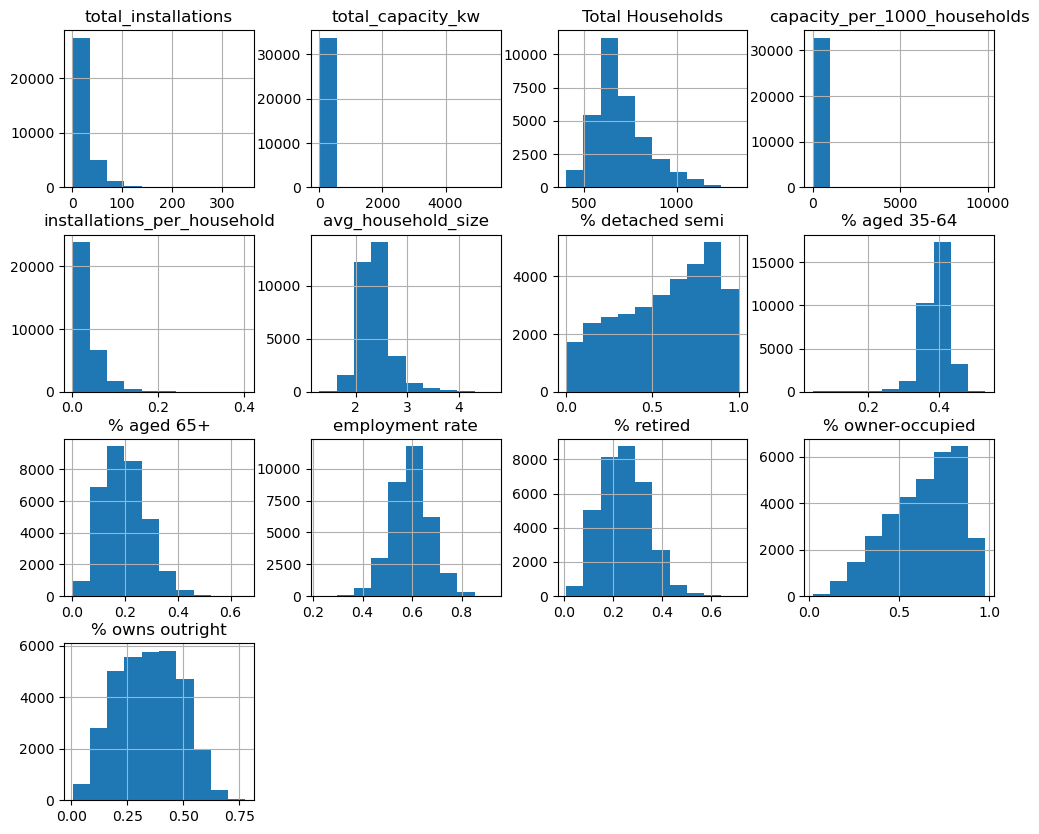

In [89]:
merged_data.hist(figsize=(12,10))

<Axes: >

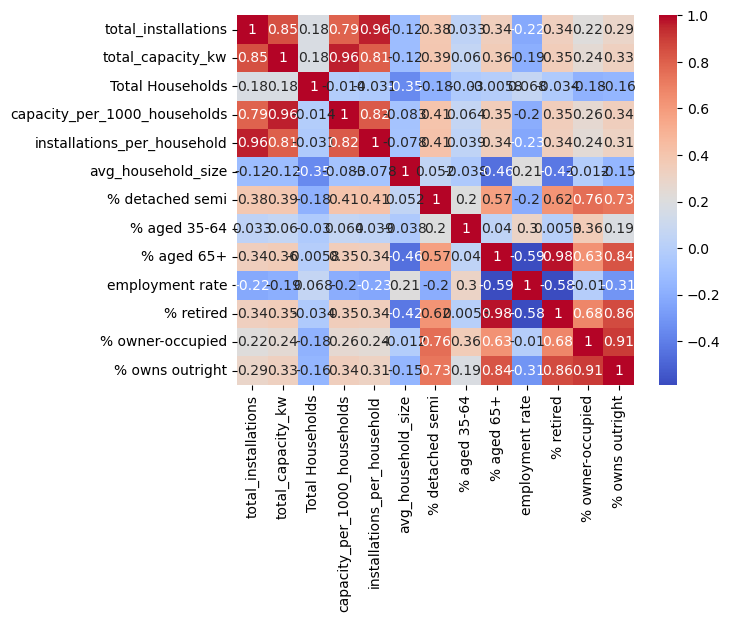

In [90]:
####### Correlation Analysis: 

numeric_data = merged_data.select_dtypes(include='number')

sns.heatmap(numeric_data.corr(), annot=True, cmap='coolwarm')

In [91]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = merged_data[['% detached semi', '% over 65 years of age', 
                 'employment rate', '% of occupied dwellings']]

vif_data = pd.DataFrame()
vif_data['feature'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif_data)

KeyError: "['% over 65 years of age', '% of occupied dwellings'] not in index"